# Notebook 03 — Evaluación y Grad-CAM
## Interpretabilidad del Clasificador SEM

**Contenido:**
1. Evaluación completa en test set (Accuracy, F1, AUC-ROC)
2. Matriz de confusión
3. Grad-CAM: visualización de regiones de activación
4. Análisis de errores
5. Exportación de métricas para el sistema multi-agente

In [1]:
# ============================================================
# WARM-UP: Imports y carga del modelo
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import json
from pathlib import Path
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    accuracy_score, f1_score, precision_score, recall_score
)
import seaborn as sns

# Configuración
PROJECT_ROOT = Path('..').resolve()
with open(PROJECT_ROOT / 'reports' / 'dataset_config.json') as f:
    cfg = json.load(f)

DATA_PROCESSED = Path(cfg['data_processed'])
CLASSES = cfg['classes']
IMAGENET_MEAN = cfg['imagenet_mean']
IMAGENET_STD = cfg['imagenet_std']
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Cargar modelo
model = models.resnet18(weights=None)
model.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(512, 2))
MODEL_PATH = PROJECT_ROOT / 'models' / 'best_sem_classifier.pth'
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model = model.to(device)
model.eval()

# DataLoader test
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
test_dataset = datasets.ImageFolder(str(DATA_PROCESSED / 'test'), transform=eval_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f'Modelo cargado: {MODEL_PATH.name}')
print(f'Test set: {len(test_dataset)} imágenes')
print(f'Device: {device}')

Modelo cargado: best_sem_classifier.pth
Test set: 107 imágenes
Device: cuda


## 1. Evaluación Completa en Test Set

In [2]:
# ============================================================
# PREDICCIONES en test set
# ============================================================
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        _, preds = outputs.max(1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())  # prob clase 1

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Métricas
acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')
prec = precision_score(all_labels, all_preds, average='weighted')
rec = recall_score(all_labels, all_preds, average='weighted')

print('=' * 55)
print('MÉTRICAS EN TEST SET')
print('=' * 55)
print(f'  Accuracy:  {acc:.4f} ({acc:.1%})')
print(f'  F1-score:  {f1:.4f}')
print(f'  Precision: {prec:.4f}')
print(f'  Recall:    {rec:.4f}')
print()
print(classification_report(all_labels, all_preds, target_names=CLASSES))

MÉTRICAS EN TEST SET
  Accuracy:  0.9907 (99.1%)
  F1-score:  0.9903
  Precision: 0.9907
  Recall:    0.9907

               precision    recall  f1-score   support

nanoparticles       1.00      0.86      0.92         7
    nanowires       0.99      1.00      1.00       100

     accuracy                           0.99       107
    macro avg       1.00      0.93      0.96       107
 weighted avg       0.99      0.99      0.99       107



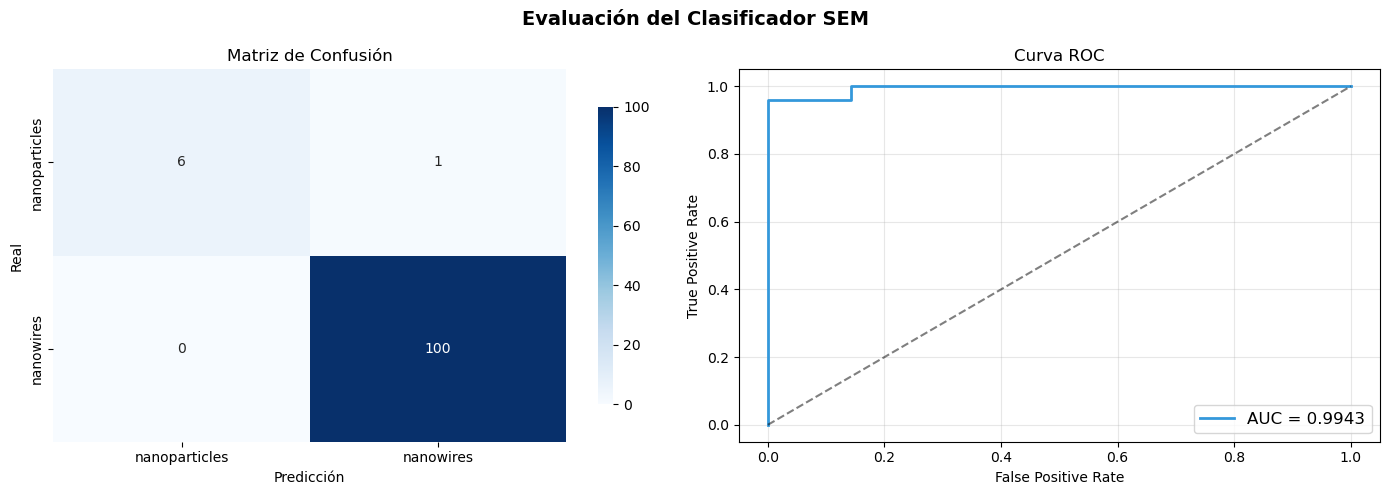

AUC-ROC: 0.9943


In [3]:
# ============================================================
# MATRIZ DE CONFUSIÓN + CURVA ROC
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES,
            yticklabels=CLASSES, ax=ax1, cbar_kws={'shrink': 0.8})
ax1.set_xlabel('Predicción')
ax1.set_ylabel('Real')
ax1.set_title('Matriz de Confusión')

# ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
ax2.plot(fpr, tpr, color='#3498db', linewidth=2, label=f'AUC = {roc_auc:.4f}')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Curva ROC')
ax2.legend(loc='lower right', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.suptitle('Evaluación del Clasificador SEM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'reports' / 'evaluation_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'AUC-ROC: {roc_auc:.4f}')

## 2. Grad-CAM: Interpretabilidad Visual

**Grad-CAM** (Gradient-weighted Class Activation Mapping) nos permite ver qué regiones de la imagen SEM son más importantes para la decisión del clasificador.

$$L^c_{\text{Grad-CAM}} = \text{ReLU}\left(\sum_k \alpha^c_k A^k\right)$$

donde $\alpha^c_k = \frac{1}{Z}\sum_i \sum_j \frac{\partial y^c}{\partial A^k_{ij}}$ son los pesos de importancia.

In [4]:
# ============================================================
# GRAD-CAM: Implementación
# ============================================================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)
    
    def _save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate(self, input_tensor, target_class=None):
        self.model.eval()
        output = self.model(input_tensor)
        
        if target_class is None:
            target_class = output.argmax(dim=1).item()
        
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, target_class] = 1.0
        output.backward(gradient=one_hot)
        
        # Pesos: promedio global de los gradientes
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)  # α_k
        
        # Mapa de calor: combinación ponderada de activaciones
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)  # Solo activaciones positivas
        cam = F.interpolate(cam, size=input_tensor.shape[2:], mode='bilinear', align_corners=False)
        
        # Normalizar a [0, 1]
        cam = cam.squeeze()
        if cam.max() > 0:
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        
        return cam.cpu().numpy(), target_class, F.softmax(output, dim=1)[0].detach().cpu().numpy()

# Inicializar Grad-CAM en la última capa convolucional de ResNet-18 (layer4)
grad_cam = GradCAM(model, model.layer4[-1])
print('Grad-CAM inicializado (target: layer4[-1])')

Grad-CAM inicializado (target: layer4[-1])


c:\Users\foxyv\miniconda3\envs\ia_nano\Lib\site-packages\torch\autograd\graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


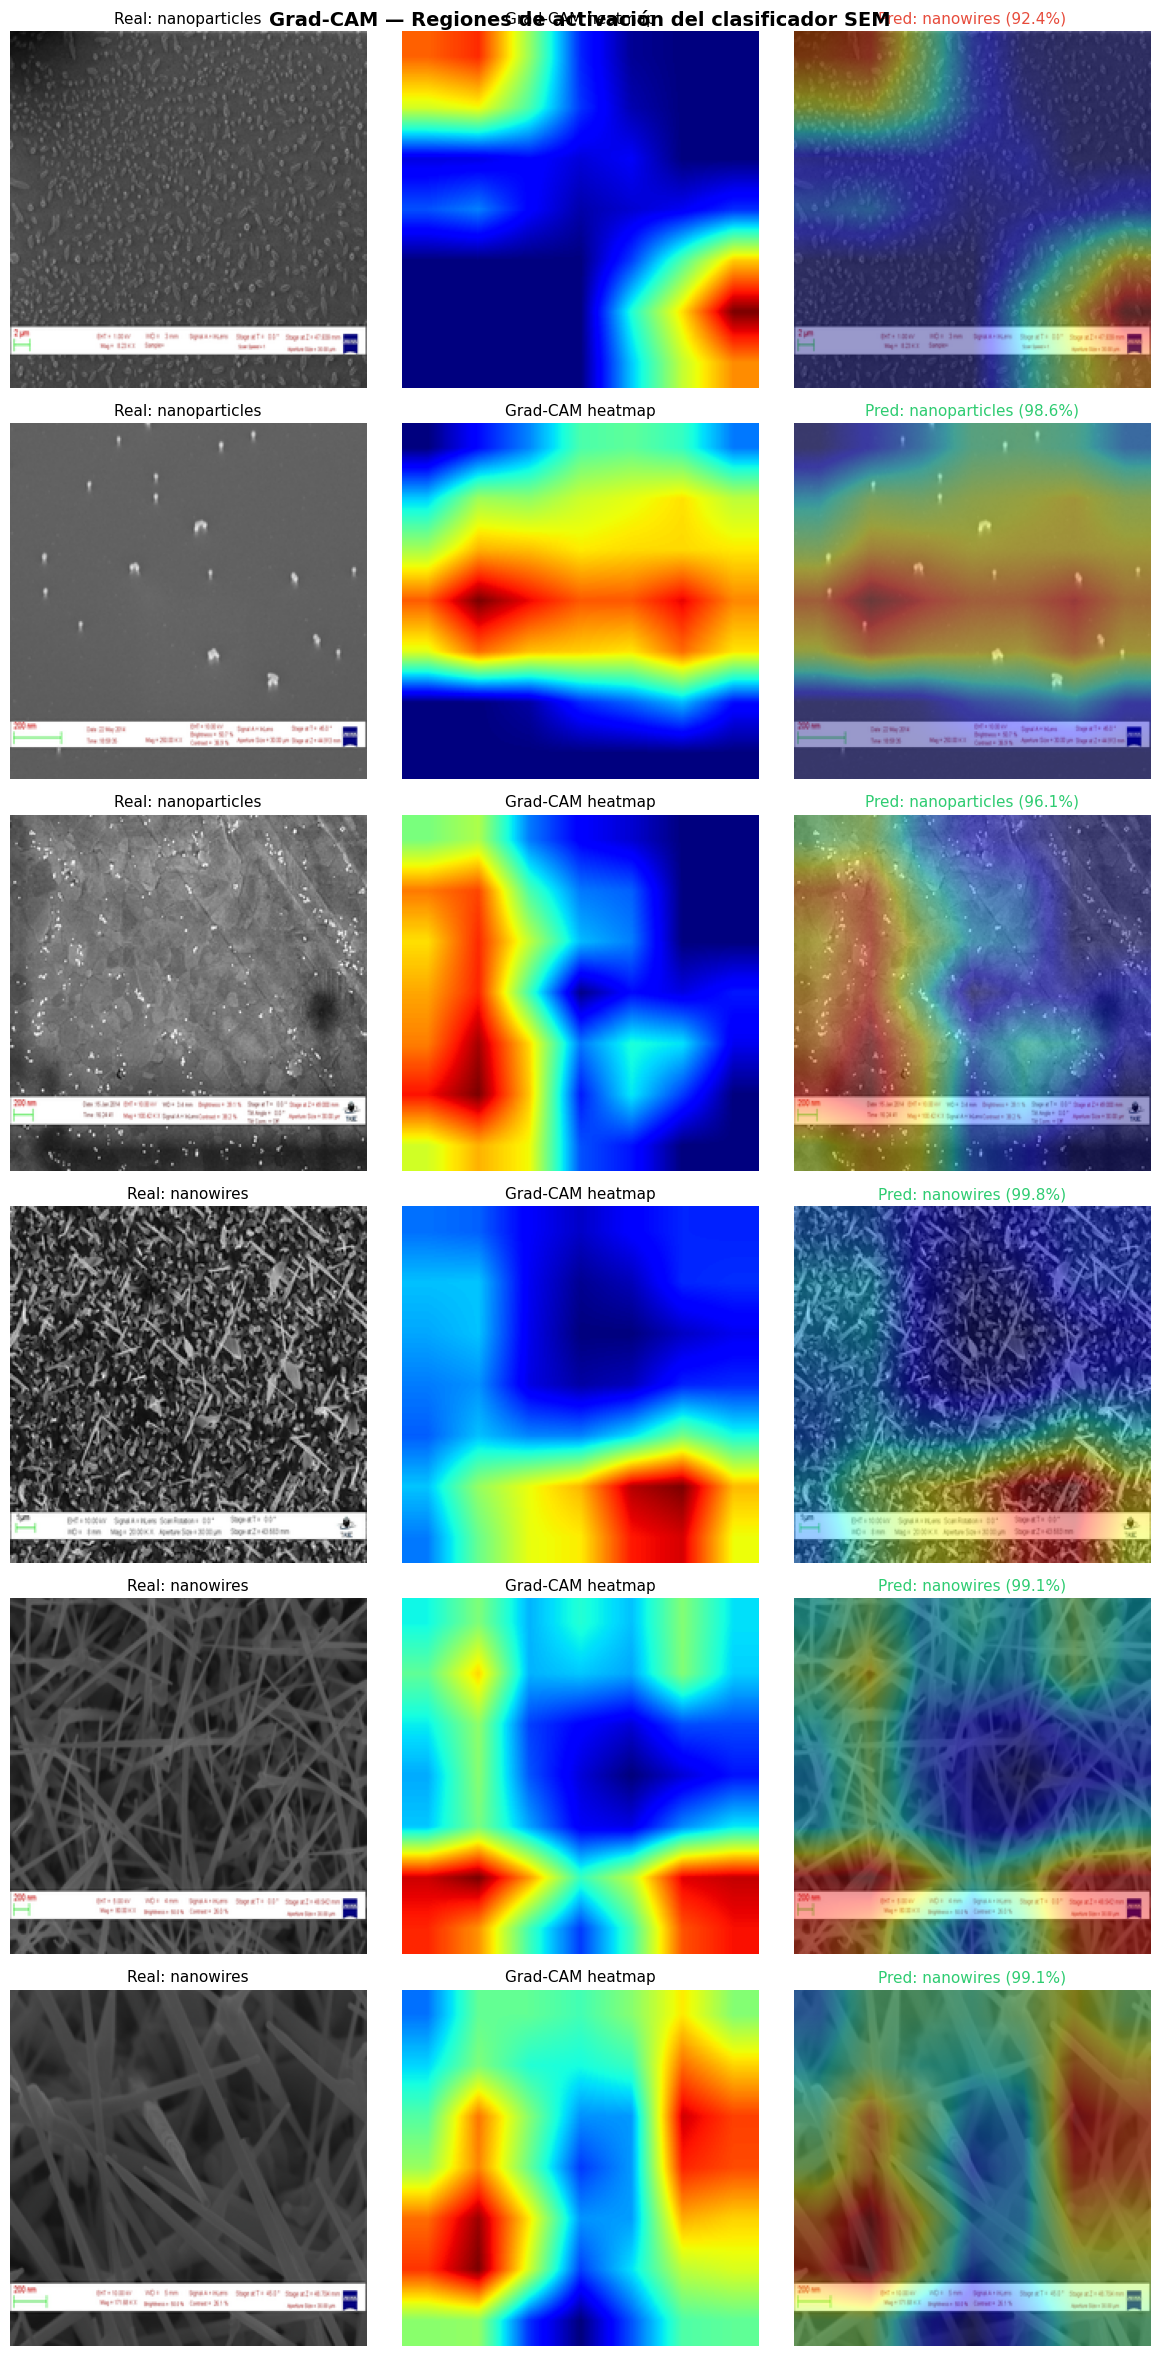

In [5]:
# ============================================================
# GRAD-CAM: Visualización de 3×3 grid
# ============================================================
def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    t = tensor.clone()
    for c, m, s in zip(t, mean, std):
        c.mul_(s).add_(m)
    return t.clamp(0, 1)

# Seleccionar muestras de cada clase
samples_per_class = 3
sample_indices = []
for cls_idx in range(2):
    cls_indices = [i for i, (_, label) in enumerate(test_dataset.samples) if label == cls_idx]
    sample_indices.extend(cls_indices[:samples_per_class])

fig, axes = plt.subplots(len(sample_indices), 3, figsize=(12, 4 * len(sample_indices)))

for row, idx in enumerate(sample_indices):
    image, label = test_dataset[idx]
    input_tensor = image.unsqueeze(0).to(device)
    
    # Generar Grad-CAM
    cam, pred_class, probs = grad_cam.generate(input_tensor)
    
    # Imagen original
    img_rgb = denormalize(image).permute(1, 2, 0).numpy()
    
    # Col 1: Original
    axes[row, 0].imshow(img_rgb)
    real_label = CLASSES[label]
    axes[row, 0].set_title(f'Real: {real_label}', fontsize=11)
    axes[row, 0].axis('off')
    
    # Col 2: Heatmap
    axes[row, 1].imshow(cam, cmap='jet')
    axes[row, 1].set_title('Grad-CAM heatmap', fontsize=11)
    axes[row, 1].axis('off')
    
    # Col 3: Superposición
    axes[row, 2].imshow(img_rgb)
    axes[row, 2].imshow(cam, cmap='jet', alpha=0.4)
    pred_label = CLASSES[pred_class]
    conf = probs[pred_class]
    color = '#2ecc71' if pred_class == label else '#e74c3c'
    axes[row, 2].set_title(f'Pred: {pred_label} ({conf:.1%})', fontsize=11, color=color)
    axes[row, 2].axis('off')

plt.suptitle('Grad-CAM — Regiones de activación del clasificador SEM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'reports' / 'gradcam_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Análisis de Errores

Errores en test: 1 de 107 (0.9%)


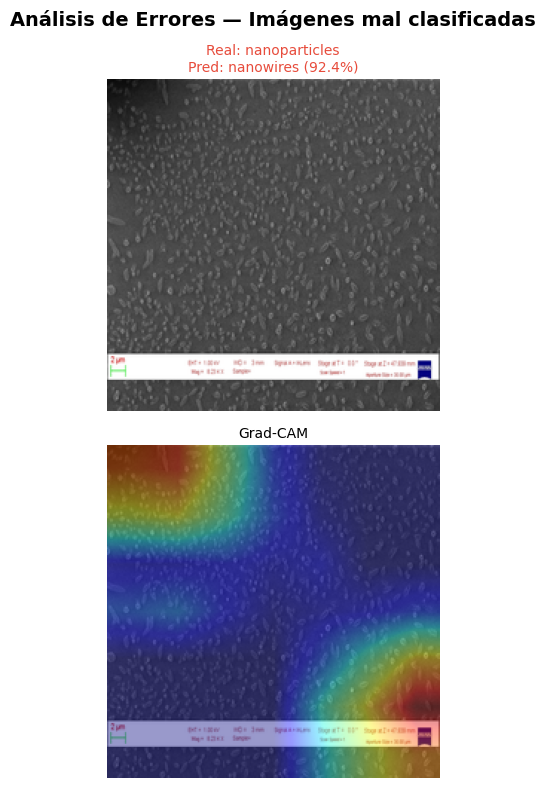

In [6]:
# ============================================================
# ANÁLISIS DE ERRORES: Imágenes mal clasificadas
# ============================================================
errors = np.where(all_preds != all_labels)[0]
print(f'Errores en test: {len(errors)} de {len(all_labels)} ({len(errors)/len(all_labels):.1%})')

if len(errors) > 0:
    n_show = min(6, len(errors))
    fig, axes = plt.subplots(2, n_show, figsize=(4*n_show, 8))
    if n_show == 1:
        axes = axes.reshape(2, 1)
    
    for col, err_idx in enumerate(errors[:n_show]):
        image, label = test_dataset[err_idx]
        input_tensor = image.unsqueeze(0).to(device)
        cam, pred_class, probs = grad_cam.generate(input_tensor)
        img_rgb = denormalize(image).permute(1, 2, 0).numpy()
        
        axes[0, col].imshow(img_rgb)
        axes[0, col].set_title(f'Real: {CLASSES[label]}\nPred: {CLASSES[pred_class]} ({probs[pred_class]:.1%})',
                              fontsize=10, color='#e74c3c')
        axes[0, col].axis('off')
        
        axes[1, col].imshow(img_rgb)
        axes[1, col].imshow(cam, cmap='jet', alpha=0.4)
        axes[1, col].set_title('Grad-CAM', fontsize=10)
        axes[1, col].axis('off')
    
    plt.suptitle('Análisis de Errores — Imágenes mal clasificadas', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(PROJECT_ROOT / 'reports' / 'error_analysis.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('¡Sin errores en test set!')

## 4. Exportar Métricas para Sistema Multi-Agente

In [7]:
# ============================================================
# EXPORTAR MÉTRICAS
# ============================================================
metrics = {
    'model': 'ResNet-18 (ImageNet → SEM fine-tuned)',
    'task': 'Binary classification: Nanoparticles (0D) vs Nanowires (1D)',
    'dataset': 'NFFA-EUROPE SEM Dataset',
    'test_size': len(test_dataset),
    'accuracy': float(acc),
    'f1_score': float(f1),
    'precision': float(prec),
    'recall': float(rec),
    'auc_roc': float(roc_auc),
    'confusion_matrix': cm.tolist(),
    'classes': CLASSES,
    'n_errors': int(len(errors)),
    'error_rate': float(len(errors) / len(all_labels)),
    'gradcam_target_layer': 'layer4[-1]',
    'gradcam_interpretation': (
        'Grad-CAM highlights edge features and aspect ratios for classification. '
        'Nanoparticles activate on rounded/spherical boundaries. '
        'Nanowires activate on elongated linear structures.'
    ),
}

metrics_path = PROJECT_ROOT / 'reports' / 'model_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f'Métricas exportadas: {metrics_path}')
print(f'\n→ Continuar con: 04_multiagent_analysis.ipynb')
print(f'  (El sistema multi-agente leerá model_metrics.json y gradcam_analysis.png)')

Métricas exportadas: C:\IA Nanotecnología\Antigravity-Nano-Research-Multiagentic-Core-main\educational_content\Proyecto final\reports\model_metrics.json

→ Continuar con: 04_multiagent_analysis.ipynb
  (El sistema multi-agente leerá model_metrics.json y gradcam_analysis.png)
